# Intelligent Methods for Resilience: Household Energy Shifting in DK1

The project investigates how data-driven electricity price signals can strengthen resilience in the Danish electricity grid by encouraging households to shift flexible electricity consumption away from high-price, grid-stressed periods and toward periods of low demand and abundant supply, thereby helping absorb excess electricity when the system struggles to balance production and consumption.

The central idea is straightforward: if households receive clear and actionable recommendations based on when electricity is expected to be cheap or expensive, part of their flexible demand can be shifted in time. This includes electricity use such as electric vehicle charging, dishwashers, washing machines, dryers, and other household consumption that can be delayed or advanced. At the household level, each shift may be small. However, when many households adjust their flexible consumption, these small changes can add up to a meaningful system-level impact, reducing grid pressure, and improving the overall resilience of the electricity system.

## Introduction: Defining resillience & Current Grid Stress in DK1

To assess grid resillience impacts we must perform grid stress analysis. The analysis of the DK1 grid uses hourly consumption data from data/consumption_dk1_raw.csv. Since the available dataset provides aggregated load by grid area rather than physical limits for specific grid assets, such as transformers, cables, or voltage levels, stress is defined statistically using the historical comsumption data. As a result, the analysis identifies periods of unusually high system demand as a proxy for physical stress of grid components. Thus the results should be interpreted with this in mind.

What is grid stress? Grid stress occurs when electricity demand, production, and network capacity are poorly aligned in time or location. In practice, this can appear as high peak loads, congestion, imbalances, steep ramps, or periods where assets such as transformers and cables operate closer to their limits.

**Operational definitions used in the analysis**

- **Low-load hour:** DK1 system load <= 1,694.4 MWh (historical 5th percentile).
- **Peak hour:** DK1 system load >= 3,269.7 MWh (historical 95th percentile).
- **Overloaded hour:** DK1 system load > 3,568.3 MWh (historical 99th percentile, used here as the as-is capacity proxy).
- **Maintenance pressure:** `load_ratio^2 + 25 * max(load_ratio - 1, 0)^2 + 0.5 * ramp_ratio`, aggregated over time.
- **Maintenance attention trigger:** 30-day rolling maintenance pressure > 497, or a clear cluster of overloaded hours in the same period.

This means the grid is treated as overloaded when hourly load moves beyond the upper band of normal historical operation. Below that level the grid still experiences wear, but once the load ratio rises above `1.0`, maintenance pressure increases nonlinearly. Low-load hours are interpreted as under-utilisation windows with spare capacity; with consumption data alone they are not treated as physical grid damage.

![DK1 baseline resilience figure](simulation_outputs/energy_congestion_resilience_baseline.png)

The combined figure shows four parts of the baseline resilience story: the system load duration curve, the seasonal/hourly load pattern, the long-horizon maintenance pressure proxy, and the grid areas with the highest cumulative stress. The underlying reproducible script is `src/analysis/energy_congestion_analysis.py`.


In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.analysis.impact_analysis import (
    load_system_consumption_df,
    add_household_load_split,
    get_central_segment_assumptions,
    add_flexible_segment_loads,
    make_segment_assumption_table,
    make_load_share_summary,
    plot_system_consumption,
    plot_household_split,
    plot_flexible_vs_inflexible,
    plot_segment_shares,
    plot_segment_loads,
    plot_shiftable_energy,
    plot_segment_shift_windows,
    plot_segment_shiftable_shares,
)

# DATA_DIR = Path("data")
# PRICE_PATH = DATA_DIR / "day_ahead_prices_dk1_raw.csv"
# CONSUMPTION_PATH = DATA_DIR / "consumption_dk1_raw.csv"
# WEATHER_ACTUAL_PATH = DATA_DIR / "weather_actuals_raw.csv"
# WEATHER_SIM_PATH = DATA_DIR / "sim_weather_forecasts_and_actuals.csv"
# WEATHER_ERROR_PATH = DATA_DIR / "weather_error_distributions.csv"


In [11]:


from src.features.feature_engineering import build_feature_matrix, get_feature_columns
from src.recommendations.decision_support import (
    generate_recommendations,
    recommendations_to_dataframe,
    summarise_forecast,
)
from src.data.simulate_impact import (
    make_daily_prices,
    simulate_daily_shift,
    plot_shift_results,
)

# DATA_DIR = Path("data")
# PRICE_PATH = DATA_DIR / "day_ahead_prices_dk1_raw.csv"
# CONSUMPTION_PATH = DATA_DIR / "consumption_dk1_raw.csv"
# WEATHER_ACTUAL_PATH = DATA_DIR / "weather_actuals_raw.csv"
# WEATHER_SIM_PATH = DATA_DIR / "sim_weather_forecasts_and_actuals.csv"
# WEATHER_ERROR_PATH = DATA_DIR / "weather_error_distributions.csv"

plt.style.use("seaborn-v0_8-whitegrid")

ModuleNotFoundError: No module named 'src.features'

## Forecast Analysis: Predicting hourly energy prices 120 hours ahead


### Data Scraping: API calls scraping energy prices, historical weather data and weather forecasts

The analysis uses local CSV files from Energi Data Service and weather data collected for DK1. The main files used in this notebook are:

- `data/day_ahead_prices_dk1_raw.csv`: day-ahead electricity prices for price area DK1.
- `data/consumption_dk1_raw.csv`: electricity consumption observations for DK1.
- `data/weather_actuals_raw.csv`: observed weather values for DK1 regions.
- `data/weather_error_distributions.csv`: estimated weather forecast errors from the period where forecast data is available.
- `data/sim_weather_forecasts_and_actuals.csv`: actual weather values together with simulated forecast values.

DK1 is relevant because it represents Western Denmark, where electricity prices are strongly affected by weather-driven renewable production, interconnectors, and changing demand. These conditions make price-based flexibility a meaningful resilience mechanism: when demand can move away from high-price periods, the grid may become less exposed to peak stress and scarcity periods.

In [ ]:
prices_raw = pd.read_csv(PRICE_PATH, parse_dates=["TimeDK", "TimeUTC"])
weather_actuals_raw = pd.read_csv(WEATHER_ACTUAL_PATH, parse_dates=["TimeDK"])
weather_sim_raw = pd.read_csv(WEATHER_SIM_PATH, parse_dates=["TimeDK"])
weather_errors = pd.read_csv(WEATHER_ERROR_PATH)
consumption_raw_preview = pd.read_csv(CONSUMPTION_PATH, nrows=10)

display(prices_raw.head())
display(weather_actuals_raw.head())
display(weather_sim_raw.head())
display(consumption_raw_preview.head())

print(f"Price rows: {len(prices_raw):,}")
print(f"Price period: {prices_raw['TimeDK'].min()} to {prices_raw['TimeDK'].max()}")
print(f"Weather actual rows: {len(weather_actuals_raw):,}")
print(f"Weather period: {weather_actuals_raw['TimeDK'].min()} to {weather_actuals_raw['TimeDK'].max()}")
print(f"Simulated weather rows: {len(weather_sim_raw):,}")

FileNotFoundError: [Errno 2] No such file or directory: 'data\\sim_weather_forecasts_and_actuals.csv'

The raw day-ahead price file contains timestamps, price area, and prices in EUR and DKK. For the rest of the project we use the DKK price because the recommendations and simulation outputs are easier to interpret for Danish households. The raw file may contain sub-hourly observations, so the forecasting feature example below resamples prices to hourly averages before using hourly lags.

The weather data is included because weather affects both electricity supply and demand. Wind speed is closely related to wind power production, shortwave radiation is related to solar production, cloud cover affects solar conditions, and temperature can influence heating and cooling demand. These variables are therefore relevant predictors for electricity prices.


### Data processing: simulate weather forecasts & prepare predictor variables


For a real-time recommender system, we cannot use actual future weather values. We need forecast weather values, because those are the values that would be available when the system makes a recommendation. Historical weather forecast data is only available for the last 12 months in our data collection, so we simulate forecast values for the older weather observations. The simulation uses error distributions estimated from the available actual forecast data. For each weather predictor and each forecast horizon, such as 24, 48, 72, 96, and 120 hours ahead, we sample a random error from the corresponding historical error distribution and add it to the actual weather value. This creates columns such as `wind_speed_10m_24` and `wind_speed_10m_120`, where larger horizons generally have larger forecast uncertainty.

The consumption file is larger because it contains grid-area observations. The project code aggregates it to daily system consumption when running the flexibility simulation.

,DKK/MWh
count,11908.000000
mean,670.397648
std,333.366186
min,-37.408167
25%,505.245657
50%,650.443338
75%,784.845719
max,3796.785229


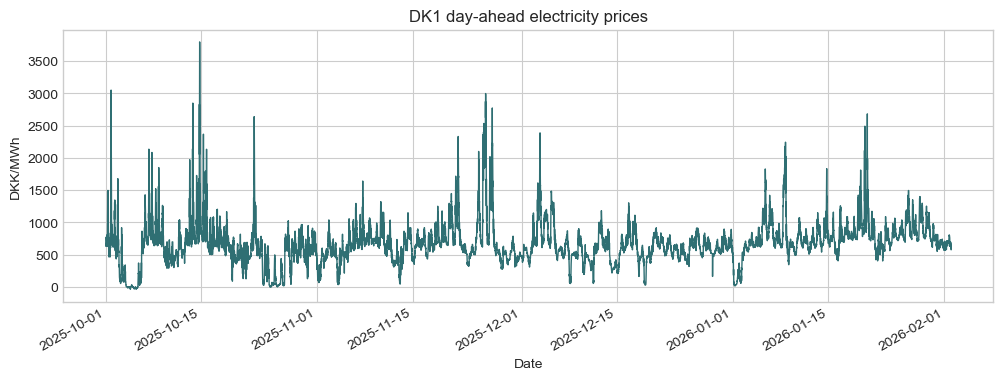

In [ ]:
price_summary = prices_raw["DayAheadPriceDKK"].describe().to_frame("DKK/MWh")
display(price_summary)

fig, ax = plt.subplots(figsize=(12, 4))
prices_raw.sort_values("TimeDK").plot(
    x="TimeDK",
    y="DayAheadPriceDKK",
    ax=ax,
    color="#2F6F73",
    linewidth=1,
    legend=False,
)
ax.set_title("DK1 day-ahead electricity prices")
ax.set_xlabel("Date")
ax.set_ylabel("DKK/MWh")
plt.show()

The next figures compare actual weather observations with simulated forecast values for four core predictor variables. We show two forecast horizons: 24 hours ahead and 120 hours ahead. Each simulated forecast is created by adding a random error sampled from the matching historical forecast-error distribution for that variable and horizon. The shaded area represents an approximate 95 percent forecast interval based on the estimated mean and standard deviation of the historical forecast error.

This plot is useful for checking whether the simulated forecasts are plausible: they should follow the same broad patterns as the actual observations, while still containing realistic forecast uncertainty.

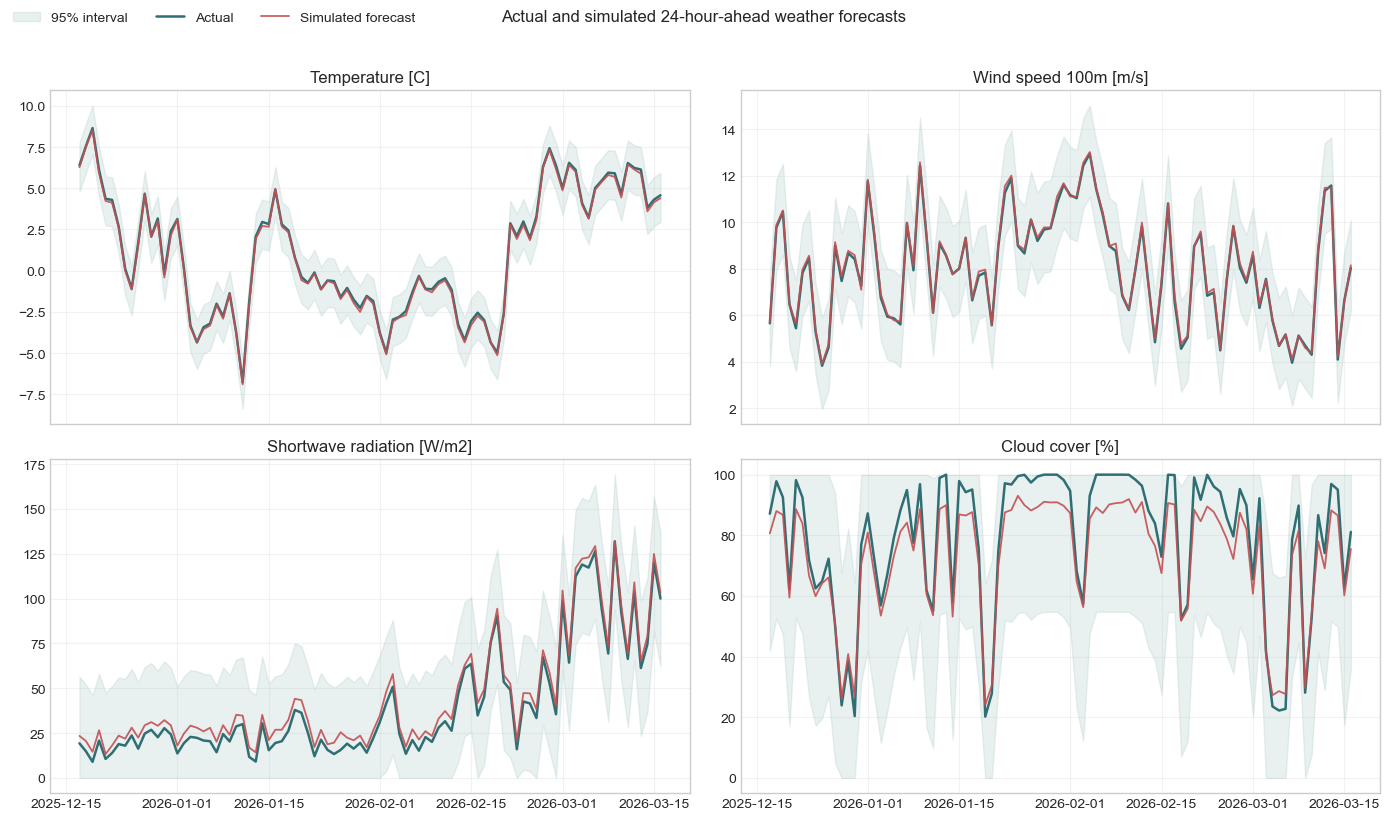

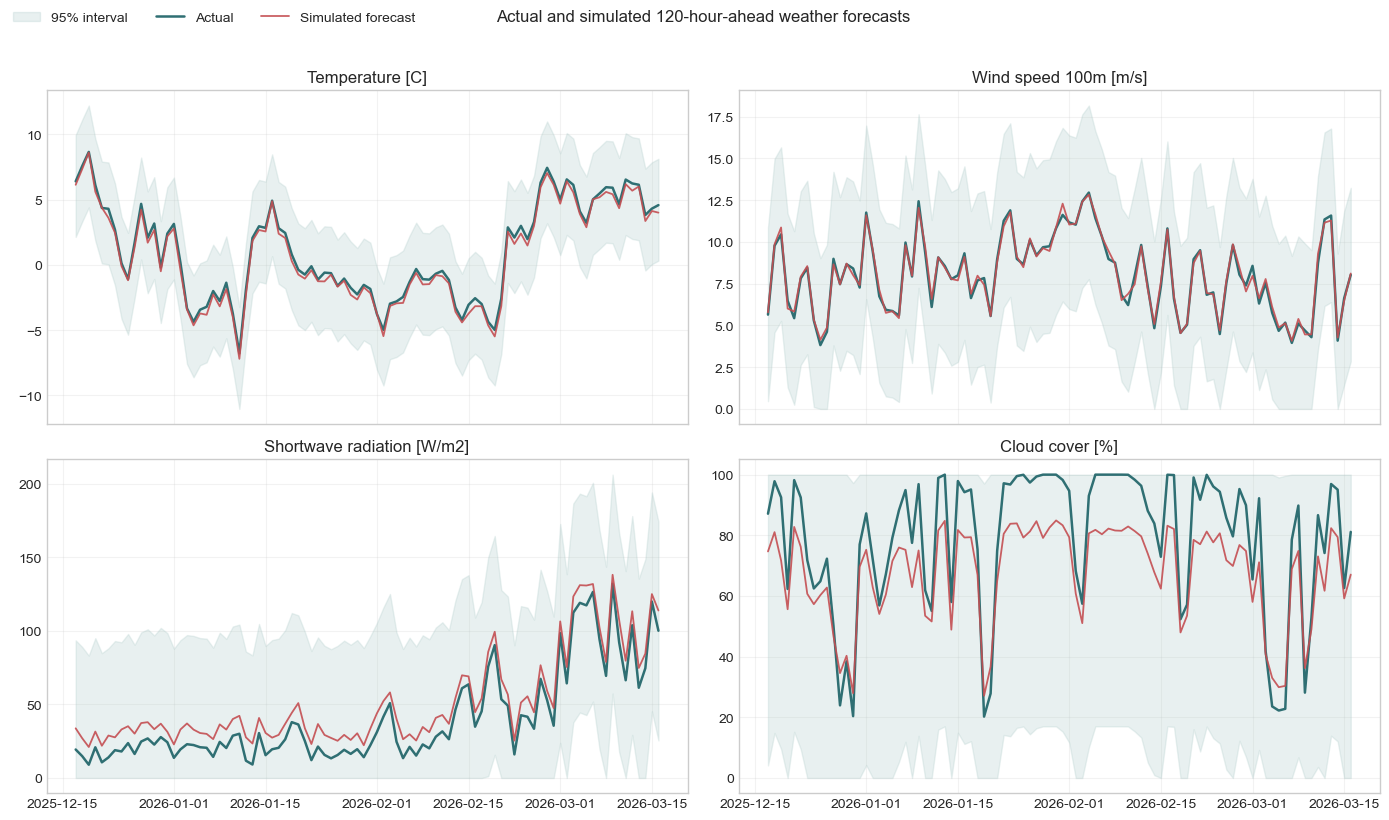

In [ ]:
weather_predictors = ["temperature_2m", "wind_speed_100m", "shortwave_radiation", "cloud_cover"]
weather_labels = {
    "temperature_2m": "Temperature [C]",
    "wind_speed_100m": "Wind speed 100m [m/s]",
    "shortwave_radiation": "Shortwave radiation [W/m2]",
    "cloud_cover": "Cloud cover [%]",
}

weather_daily_cols = [*weather_predictors]
for horizon in [24, 120]:
    weather_daily_cols.extend([f"{col}_{horizon}" for col in weather_predictors])

weather_daily = (
    weather_sim_raw.groupby([pd.Grouper(key="TimeDK", freq="D"), "region"])
    [weather_daily_cols]
    .mean()
    .groupby("TimeDK")
    .mean()
)

plot_weather = weather_daily.tail(90)

def plot_weather_forecast_grid(horizon_hours):
    error_h = weather_errors[weather_errors["horizon_hours"] == horizon_hours].set_index("actual_variable")
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

    for ax, variable in zip(axes.ravel(), weather_predictors):
        actual = plot_weather[variable]
        forecast = plot_weather[f"{variable}_{horizon_hours}"]
        mean_error = error_h.loc[variable, "mean_error"]
        std_error = error_h.loc[variable, "std_error"]
        lower = actual + mean_error - 1.96 * std_error
        upper = actual + mean_error + 1.96 * std_error

        if variable in ["wind_speed_100m", "shortwave_radiation"]:
            lower = lower.clip(lower=0)
        if variable == "cloud_cover":
            lower = lower.clip(lower=0, upper=100)
            upper = upper.clip(lower=0, upper=100)

        ax.fill_between(plot_weather.index, lower, upper, color="#A7C7C5", alpha=0.25, label="95% interval")
        ax.plot(plot_weather.index, actual, color="#2F6F73", linewidth=1.8, label="Actual")
        ax.plot(plot_weather.index, forecast, color="#C44E52", linewidth=1.3, alpha=0.9, label="Simulated forecast")
        ax.set_title(weather_labels[variable])
        ax.grid(alpha=0.25)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper left", ncol=3, frameon=False)
    fig.suptitle(f"Actual and simulated {horizon_hours}-hour-ahead weather forecasts", y=1.02)
    fig.tight_layout()
    return fig

fig_24 = plot_weather_forecast_grid(24)
plt.show()

fig_120 = plot_weather_forecast_grid(120)
plt.show()

The two weather figures show how forecast uncertainty increases with the forecast horizon. The 24-hour-ahead simulated forecasts stay relatively close to the actual weather values because short-term forecasts are usually more accurate. The 120-hour-ahead forecasts have wider uncertainty bands and larger deviations from the actual series, because five-day weather forecasts are harder to make.

This is important for the recommender system because uncertainty accumulates as we look further ahead. A five-day price trend can still be useful for households, but the system should communicate uncertainty carefully. Temperature changes relatively smoothly, while cloud cover, radiation, and wind speed can change more sharply. Since wind and solar conditions affect the DK1 electricity system, uncertainty in weather forecasts can later propagate into electricity price forecasts and recommendations.

,correlation_with_price
wind_speed_100m_120,-0.573265
temperature_2m_120,-0.365589
cloud_cover_120,-0.144574
shortwave_radiation_120,-0.040552


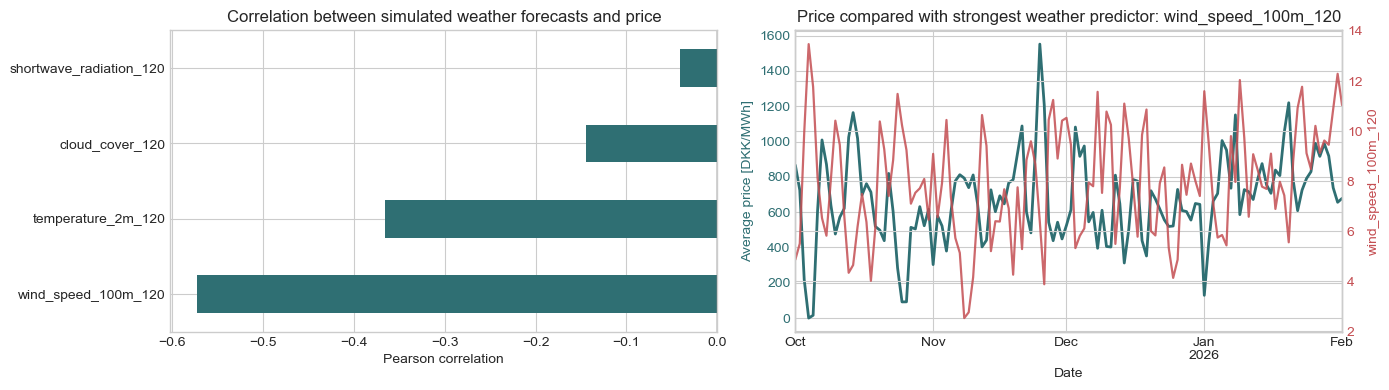

In [ ]:
price_daily = (
    prices_raw.set_index("TimeDK")["DayAheadPriceDKK"]
    .resample("D")
    .mean()
    .rename("avg_price_dkk_per_mwh")
)

correlation_horizon = 120
weather_forecast_daily = (
    weather_sim_raw.groupby([pd.Grouper(key="TimeDK", freq="D"), "region"])
    [[f"{col}_{correlation_horizon}" for col in weather_predictors]]
    .mean()
    .groupby("TimeDK")
    .mean()
)

price_weather_daily = pd.concat([price_daily, weather_forecast_daily], axis=1).dropna()

weather_correlations = (
    price_weather_daily.corr()["avg_price_dkk_per_mwh"]
    .drop("avg_price_dkk_per_mwh")
    .rename("correlation_with_price")
    .sort_values(key=abs, ascending=False)
    .to_frame()
)

display(weather_correlations)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

weather_correlations.sort_values("correlation_with_price").plot(
    kind="barh",
    ax=axes[0],
    color="#2F6F73",
    legend=False,
)
axes[0].axvline(0, color="#333333", linewidth=1)
axes[0].set_title("Correlation between simulated weather forecasts and price")
axes[0].set_xlabel("Pearson correlation")

strongest_predictor = weather_correlations.index[0]
ax_price = axes[1]
ax_weather = ax_price.twinx()

price_weather_daily["avg_price_dkk_per_mwh"].plot(
    ax=ax_price,
    color="#2F6F73",
    linewidth=2,
    label="Average price",
)
price_weather_daily[strongest_predictor].plot(
    ax=ax_weather,
    color="#C44E52",
    linewidth=1.6,
    alpha=0.85,
    label=strongest_predictor,
)

ax_price.set_title(f"Price compared with strongest weather predictor: {strongest_predictor}")
ax_price.set_xlabel("Date")
ax_price.set_ylabel("Average price [DKK/MWh]", color="#2F6F73")
ax_weather.set_ylabel(strongest_predictor, color="#C44E52")
ax_price.tick_params(axis="y", labelcolor="#2F6F73")
ax_weather.tick_params(axis="y", labelcolor="#C44E52")

fig.tight_layout()
plt.show()

The correlation plot compares the target variable, average DK1 electricity price, with the simulated weather forecast predictors. These correlations should not be interpreted as causal effects, because electricity prices also depend on demand, interconnectors, fuel prices, outages, and market expectations. They do, however, show whether each weather variable contains useful statistical information for forecasting prices.

A negative correlation means that higher values of the weather predictor tend to occur together with lower electricity prices. For example, stronger wind conditions may be associated with lower prices because wind production increases supply. A positive correlation means that higher values of the predictor tend to occur together with higher prices. Temperature, radiation, and cloud cover can matter through both supply and demand channels.

For the project objective, the important point is that the recommender system must work with information available before the consumption decision is made. Simulated forecast weather data lets us train and evaluate the price forecasting workflow in a way that resembles real-time use: the model receives forecasted weather predictors, produces a 5-day price trend, and households can use that trend to shift flexible consumption to cheaper windows.

In [ ]:
hourly_prices = (
    prices_raw.rename(columns={"TimeDK": "HourDK", "DayAheadPriceDKK": "SpotPriceDKK"})
    .sort_values("HourDK")
    .set_index("HourDK")[["SpotPriceDKK"]]
    .resample("h")
    .mean()
    .dropna()
)

features_24h = build_feature_matrix(hourly_prices, forecast_horizon=24, drop_na=True)
feature_columns = get_feature_columns(features_24h)

print(f"Feature matrix shape: {features_24h.shape}")
print(f"Number of model features: {len(feature_columns)}")
display(features_24h.head())

Feature matrix shape: (2784, 51)
Number of model features: 49


c:\Users\rebec\OneDrive\Dokumenter\GitHub\Advanced-Business-Analytics\src\features\feature_engineering.py:54: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df["is_danish_holiday"] = idx.normalize().isin(dk_holidays).astype(int)


,SpotPriceDKK,y,hour,day_of_week,month,year,day_of_year,week_of_year,is_weekend,is_danish_holiday,...,rolling_min_48h,rolling_max_48h,rolling_mean_168h,rolling_std_168h,rolling_min_168h,rolling_max_168h,price_diff_1h,price_diff_24h,price_pct_change_24h,price_pct_change_168h
HourDK,,,,,,,,,,,,,,,,,,,,,
2025-10-08 00:00:00,697.781778,725.903633,0,2,10,2025,281,41,0,0,...,67.965637,2014.15675,491.349555,473.561452,-27.290789,2538.350036,-30.060734,-50.816774,-0.067883,0.020723
2025-10-08 01:00:00,660.336281,691.313686,1,2,10,2025,281,41,0,0,...,67.965637,2014.15675,491.433880,473.597153,-27.290789,2538.350036,-37.445497,-41.393186,-0.058987,0.025056
2025-10-08 02:00:00,653.784248,696.372443,2,2,10,2025,281,41,0,0,...,67.965637,2014.15675,491.529958,473.629965,-27.290789,2538.350036,-6.552033,-16.811177,-0.025069,0.031776
2025-10-08 03:00:00,649.416249,661.241147,3,2,10,2025,281,41,0,0,...,80.136358,2014.15675,491.649807,473.668689,-27.290789,2538.350036,-4.367999,-19.181968,-0.028690,-0.015179
2025-10-08 04:00:00,669.557661,692.172351,4,2,10,2025,281,41,0,0,...,125.440565,2014.15675,491.590228,473.648088,-27.290789,2538.350036,20.141412,-24.612287,-0.035456,0.023126


The target column `y` is the future electricity price at the chosen forecast horizon. For a 24-hour horizon, each row describes what was known at a given hour and links it to the price one day later.

This structure is important for resilience because households need forward-looking information. A recommendation is only useful if it tells the user whether it is better to consume now or wait for a future window.

### XGBoost Forecasting Model


The forecasting engine consists of five separate XGBoost models, one per forecast day. Each model is trained exclusively on rows whose `horizon_h` falls within that day's window (Day 1: h = 1–24, Day 2: h = 25–48, and so on through Day 5: h = 97–120). This avoids a single model having to simultaneously represent both short- and long-horizon dynamics, which have structurally different error profiles.

All five models use the quantile regression objective (`reg:quantileerror`) with `quantile_alpha = 0.50`, making the median — not the mean — the optimisation target. This is the MAE-optimal point forecast and is more robust to the price spikes that characterise electricity markets than the mean squared error objective.

Walk-forward cross-validation is used throughout. An initial training window of 12 months is expanded quarterly, yielding approximately 12–15 folds across the four years of available data. Predictions from all folds are collected into a single out-of-sample prediction record.



In [ ]:
#function that predicts given processed data
#function with plot over historic and predicted prices


### Uncertainty: Residual analysis 

The ±1σ confidence band displayed around each forecast is derived entirely from the historical walk-forward residuals — it does not require a separate model. The construction proceeds in three steps:

1. **Residual computation.** For every out-of-sample prediction in the walk-forward record, the signed error is computed as  = \hat{y} - y$, where $\hat{y}$ is the model prediction and $ is the realised price.

2. **Post-crisis filtering.** Only residuals from 1 January 2023 onwards are retained. The European energy crisis of 2022 produced volatility that is not representative of current market conditions; including those observations would artificially inflate the estimated uncertainty.

3. **Horizon-specific standard deviation.** The residuals are grouped by `horizon_h` and the standard deviation $\sigma_h$ is computed within each group, yielding 120 distinct values — one per hour ahead — which capture the well-known pattern that forecast uncertainty grows with the forecast horizon.

The band is then drawn as $\hat{y}_h \pm \sigma_h$ around the point forecast. Each $\sigma_h$ is estimated from approximately 2,000 independent residuals (roughly 180 issue times per fold across 12 folds), giving a stable estimate that is not sensitive to individual outlier observations.

This approach is intentionally simple and interpretable: it describes how wrong the model has historically been at each horizon, expressed in the same units as the forecast itself (DKK/MWh).

In [ ]:
#function with plot over pridicted prices with intervals and some residual analysis plots


## Explainable AI: SHAP & Lime to explain the prediction model

In [ ]:
#function with shap plots for feature importance and dependence plots for top features

In [ ]:
#function with lime plots for local explanations of specific predictions

## User dashboard: Household Recommendations

Forecasts alone are not enough for most households. A table of predicted prices is technically useful, but it does not automatically answer the practical question: **Should I run this flexible load now or later?**

The recommendation layer in `src/recommendations/decision_support.py` translates a probabilistic forecast into plain-language messages. It identifies cheap and expensive periods relative to recent price levels and highlights the best saving opportunity.

In [ ]:
# Draft forecast-like input based on the latest observed prices.
# In the full project this table would come from the trained forecasting model.
forecast_horizons = [1, 3, 6, 12, 24, 48, 72, 96, 120, 144, 168]
latest_prices = hourly_prices.tail(max(forecast_horizons))["SpotPriceDKK"].reset_index(drop=True)

forecast_df = pd.DataFrame(
    {
        "horizon_h": forecast_horizons,
        "q0.10": [latest_prices.iloc[-h] * 0.85 for h in forecast_horizons],
        "q0.50": [latest_prices.iloc[-h] for h in forecast_horizons],
        "q0.90": [latest_prices.iloc[-h] * 1.15 for h in forecast_horizons],
    }
).set_index("horizon_h")

current_price = float(hourly_prices["SpotPriceDKK"].iloc[-1])
recent_history = hourly_prices["SpotPriceDKK"].tail(24 * 30)

forecast_summary = summarise_forecast(forecast_df)
recommendations = generate_recommendations(
    forecast_df,
    current_price_dkk=current_price,
    historical_prices=recent_history,
)

display(pd.Series(forecast_summary, name="forecast_summary"))
display(recommendations_to_dataframe(recommendations))

min_median                  612.737494
max_median                  859.625610
mean_median                 730.431484
cheapest_horizon_h            1.000000
most_expensive_horizon_h    144.000000
price_range_dkk             246.888117
Name: forecast_summary, dtype: float64

,horizon_h,category,message,estimated_saving_dkk_per_mwh,lower_price_dkk,median_price_dkk,upper_price_dkk
0,1,cheap,Electricity is expected to be cheap in 1 hour ...,None,520.8,612.7,704.6
1,3,cheap,Electricity is expected to be cheap in 3 hours...,None,581.2,683.8,786.4


This step connects analytics to behavior. The recommendation does not require the household to understand quantile regression or electricity-market dynamics. Instead, it communicates whether waiting is expected to be valuable and whether an upcoming period looks unusually expensive.

For a real deployment, the forecast table would be produced by the trained price model. In this notebook draft, the same recommendation functions are demonstrated with a forecast-like table so the logic is visible and easy to inspect.

## Modelling of impact: Rolling 120 hour heuristic

intro do why it is important, how the heuristic models and what assumptions that are required 


### Estimating Household and Non-Household Load

Using the household share assumption, we divide total system consumption into two broad components:

$$
SystemLoad_t = HouseholdLoad_t + ResidualLoad_t
$$

where:

$$
HouseholdLoad_t = 0.32 \cdot SystemLoad_t
$$

and:

$$
ResidualLoad_t = 0.68 \cdot SystemLoad_t
$$

This split is deliberately simple. The purpose is not to reconstruct the exact hourly load of every Danish household, but to create a transparent baseline for testing how household flexibility could affect the system profile.

In [ ]:
HOUSEHOLD_SHARE_OF_SYSTEM_LOAD = 0.32

load_df = add_household_load_split(
    hourly_consumption,
    household_share=HOUSEHOLD_SHARE_OF_SYSTEM_LOAD,
)

load_df.head()

In [ ]:
plot_household_split(load_df)

### Flexible and Inflexible Household Consumption

Not all household electricity consumption is suitable for shifting. Some demand is tied to immediate use, such as cooking, lighting, entertainment, standby consumption, and occupancy-driven appliance use. This part of household load is treated as **inflexible** and remains in the original hour.

The simulation focuses on the subset of household load that can realistically be shifted while still delivering the same energy service. Danish household electricity research supports this modelling approach by showing that household consumption can be decomposed into appliance and end-use categories, and that future electrification through electric vehicles and heat pumps is especially important for peak demand and demand response. :contentReference[oaicite:1]{index=1}

For the central case, we assume that approximately **29.2% of household electricity consumption is potentially flexible**, while the remaining **70.8% is inflexible**. This should be interpreted as a scenario assumption. It can be changed later in sensitivity analysis.

In [ ]:
segment_assumptions = get_central_segment_assumptions()

segment_assumption_table = make_segment_assumption_table(segment_assumptions)
segment_assumption_table

In [ ]:
load_df = add_flexible_segment_loads(
    load_df,
    segment_assumptions=segment_assumptions,
)

share_summary = make_load_share_summary(segment_assumptions)
share_summary

In [ ]:
plot_flexible_vs_inflexible(load_df)

### Flexible Load Segments

The flexible household load is divided into six segments. These categories are chosen because they represent loads where the timing of electricity use can be changed without removing the underlying energy service.

The Danish ELMODEL-bolig framework is an example of a bottom-up household electricity model that decomposes Danish household electricity consumption by appliance type. It includes appliance stock, appliance-specific electricity use, and usage assumptions. This supports the idea that household electricity demand should not be treated as one homogeneous block. :contentReference[oaicite:2]{index=2}

| Segment | Interpretation | Flexibility logic |
|---|---|---|
| EV charging | Home charging of electric vehicles | Energy can be shifted until the vehicle is needed |
| Home battery / stationary storage | Residential battery charging | Can move electricity across hours, but current adoption is low |
| Thermal heating | Heat pumps and electric heating in well-insulated homes | Can pre-heat or reduce heating temporarily within comfort limits |
| Laundry | Washing machines and tumble dryers | Can often be delayed to lower-price hours |
| Dishwasher | Dishwasher cycles | Can often be delayed to night-time or low-price periods |
| Other flexible loads | Small shiftable loads such as e-bike charging, appliance charging, robot vacuuming, or discretionary loads | Limited but non-zero flexibility |

EVs and heat pumps are especially relevant for future flexibility. Danish household research highlights that these technologies can substantially increase household electricity demand and are important targets for demand response. EV adoption is also increasing in Denmark; EVs made up 51.5% of Danish passenger car sales in 2024 and around 12% of the total vehicle fleet, which explains why EV charging is meaningful but still limited at aggregate household level. :contentReference[oaicite:3]{index=3}

In [ ]:
plot_segment_shares(segment_assumption_table)

The figure above shows the segment assumptions as a share of total household electricity consumption. Thermal heating and EV charging are the largest flexible categories in the central case, while home batteries are included as a highly flexible but currently very small aggregate category.

Because this simulation is performed at aggregate DK1 level, the segment shares should not be interpreted as the consumption split inside a single household. For example, an EV-owning household may use a large share of its electricity for vehicle charging, but many households do not own an EV. The model therefore assigns EV charging a lower aggregate share.

In [ ]:
plot_segment_loads(load_df, segment_assumptions)

### Modelling Price-Sensitive Behaviour

The recommender system is based on the idea that consumers respond to forecasted price differences. This means that flexible consumption is not shifted randomly. Instead, the model evaluates whether moving a load from its original hour to a later hour creates enough value.

The price signal comes from the XGBoost model, which produces hourly price forecasts for the next 120 hours. The shift model uses this forecast as an external input. At each decision point, flexible loads are allowed to either remain in the current hour or move to a future hour within a segment-specific waiting window.

The current hour is always included as a valid option. This is important because the model should be able to conclude that the best recommendation is to do nothing.

In [ ]:
plot_segment_shift_windows(segment_assumption_table)

NameError: name 'segment_assumption_table' is not defined

In [ ]:
plot_segment_shiftable_shares(segment_assumption_table)

Each segment has four central parameters:

\[
LoadShare_s
\]

defines how much of aggregate household demand belongs to the segment.

\[
MaxShiftableShare_s
\]

defines the share of the segment load that can actually be moved.

\[
MaxWait_s
\]

defines how far into the future the load can be shifted.

\[
WaitPenalty_s
\]

represents inconvenience or technical constraints from delaying the load.

The assumptions reflect that some loads are technically flexible but behaviorally constrained. For example, home batteries can theoretically respond over the full 120-hour forecast horizon, while dishwashers and laundry are usually limited to shorter windows. Thermal heating is constrained by comfort and building physics, so the allowed waiting window is shorter.

### Building Baseline and Flexible Columns for the Shift Model

The shifting heuristic expects two columns per segment:

1. a baseline load column;
2. a flexible load column.

The baseline column represents the estimated load of the segment in each hour. The flexible column represents the part of that segment that the model is allowed to move. This distinction is important because even within a flexible category, not all consumption is perfectly controllable.

In [ ]:
baseline_cols = [
    f"{segment}_baseline_mwh"
    for segment in segment_assumptions.keys()
]

flexible_cols = [
    f"{segment}_flexible_mwh"
    for segment in segment_assumptions.keys()
]

load_df[["datetime"] + baseline_cols + flexible_cols].head()

In [ ]:
plot_shiftable_energy(load_df)

The flexible segment baseline is larger than the actually shiftable energy because only part of each segment is assumed to be movable. This is an important modelling safeguard. Without it, the simulation would overstate the possible demand response by assuming that every EV, heat pump, dishwasher, and laundry cycle is perfectly controllable.

### Linking the Load Model to the Forecast-Based Recommendation

The final step is to connect the estimated flexible load with the price forecast. The recommender system evaluates possible target hours for each flexible load segment and scores each candidate hour using four dimensions:

\[
score =
w_{price} \cdot price\_score
+
w_{wait} \cdot wait\_penalty
+
w_{peak} \cdot grid\_pressure
-
w_{surplus} \cdot surplus\_reward
\]

A lower score means that the hour is more attractive. The model therefore prefers hours with lower forecasted prices, lower system stress, and higher renewable surplus. Waiting too long increases the score, reflecting inconvenience or technical limits.

A shift is accepted only if the best target hour is different from the current hour, the score improvement is large enough, and the move does not create a new peak. This is important because price-based shifting can otherwise create rebound effects, where too much demand moves into the same cheap hour.

In [ ]:
decision_weights = {
    "price": 1.00,
    "wait": 0.40,
    "peak": 0.50,
    "surplus": 0.30,
    "min_gain": 0.05,
}

decision_weights

At this point, the dataframe contains the estimated household load, the inflexible household load, the flexible load segments, and the maximum shiftable energy by segment. This becomes the load-side input to the hourly shift heuristic.

The current `impact_analysis.py` script prepares this load-side input. The next missing step is an hourly shift function that combines these columns with the XGBoost 120-hour price forecast and returns shifted load, shifted-out energy, shifted-in energy, and KPI summaries.

In [ ]:
prepared_load_path = Path("outputs/model/prepared_household_flex_load.csv")
prepared_load_path.parent.mkdir(parents=True, exist_ok=True)

load_df.to_csv(prepared_load_path, index=False)

prepared_load_path

### Interpretation Before Running the Shift Simulation

This preparation step creates a transparent baseline for the impact analysis. It does not yet claim that households will shift automatically. Instead, it defines the amount of household electricity that could plausibly respond to a forecast-based recommendation.

The central assumptions are:

- households represent approximately 32% of total system electricity consumption;
- around 70-80% of household electricity is treated as inflexible;
- the flexible portion is split into EV charging, home battery storage, thermal heating, laundry, dishwasher, and other flexible loads;
- each segment has its own flexibility window and shiftable share;
- price forecasts trigger shifting only when the expected benefit is large enough.

The resulting simulation should therefore be interpreted as a **forecast-guided flexibility scenario**. It estimates what could happen if a price-sensitive share of households responds to the recommender system. The value of the simulation is not only consumer cost savings, but also whether flexible demand can be moved away from stressed hours and toward low-price or renewable-surplus hours.

In [ ]:
#function that runs the simulation over 90 days period
#plot of current vs shifted consumption, plot of net shifted energy together with the price curves


## 8. Comparing Impact Sensitivity of the Forecast Model

Because the electricity price forecast is uncertain, we include a sensitivity analysis of the simulated grid impact. The question is: how much does the estimated resilience effect change if the forecasted future prices are systematically too low or too high?

This matters because households make shifting decisions based on predicted price differences. If the model underestimates or overestimates future prices, it may recommend too much or too little shifting. Comparing scenarios such as `-10% forecast bias`, `baseline`, and `+10% forecast bias` helps show how accurate the model needs to be for the recommender to support grid resilience reliably.

The sensitivity figures show how the estimated impact changes when the model's future price forecasts are shifted downward or upward. If future prices are forecast too low, the model sees more attractive saving opportunities and recommends more shifting. If future prices are forecast too high, fewer future periods look cheap, so the simulated household response becomes weaker.

This result is important for the resilience argument. The forecasting model does not need to predict every price perfectly, but it does need to capture the direction and relative size of upcoming price changes. A useful 5-day trend forecast can support household action, while a biased forecast can reduce the quality of recommendations and weaken the simulated grid benefit.

## 9. Discussion: Resilience Contribution, Assumtions & Limitation

The project contributes to grid resilience in three ways.

First, it improves **situational awareness** by using historical electricity data to describe and forecast price patterns. Prices are not a perfect measure of grid stress, but they often reflect scarcity, congestion, and changing supply-demand conditions.

Second, it improves **decision quality** for households. Rather than asking consumers to manually inspect price tables, the recommendation layer converts analytics into short and actionable guidance.

Third, it supports **demand flexibility**. If many households shift flexible consumption, the aggregated effect can reduce peaks and make demand less rigid. This matters in an electricity system with high renewable production, where both supply and demand need to become more adaptive.



This draft has several important limitations that should be discussed in the final hand-in.

- The household response model is scenario-based, not estimated from observed household behavior.
- The simulation uses daily aggregation, while real household flexibility often happens within the day.
- Price is used as the main signal, although grid stress also depends on local network constraints, production mix, weather, and interconnector flows.
- The recommendation example in this notebook uses a forecast-like table for demonstration. A final version should connect directly to a trained forecasting model if the model module is completed.
- Flexible consumption is assumed to be shifted rather than cancelled, which is reasonable for tasks such as EV charging and appliances but less accurate for all load types.

These limitations do not remove the project value. They clarify what the model can and cannot claim: it is best understood as a decision-support and impact-simulation framework for exploring household flexibility as a resilience resource.

## Conclusion

This project shows how business analytics can connect data, forecasting, recommendations, and system-level impact. The technical workflow starts with DK1 electricity price and consumption data, builds time-series features, translates price signals into household guidance, and simulates how flexible demand could shift across days.

The main conclusion is that household flexibility can contribute to energy-grid resilience when analytics are made actionable. Forecasts create information, recommendations create usable decisions, and coordinated household response can help reduce system stress.